<a href="https://colab.research.google.com/github/brendanpshea/database_sql/blob/main/Database_01_StarShipSQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Starship SQL: An Introduction to Databases
## Databases Through Pop Culture: Brendan Shea, PhD

This chapter introduces databases using Star Trek as an extended analogy. You will explore the distinctions between data, information, and knowledge; compare relational, document, and graph data models; walk through conceptual, logical, and physical modeling; and consider how DBMS choice, storage location, and analytical structures like data lakes, warehouses, and marts fit together.

## Learning Outcomes

By the end of this chapter, you will be able to:

1. Distinguish among data, information, and knowledge, and explain how databases help turn raw data into useful information.
2. Compare flat files and databases in terms of organization, consistency, and retrieval.
3. Differentiate conceptual, logical, and physical data models and identify entities and relationships in simple ERDs.
4. Compare relational, document, graph, and column-oriented data models and match them to appropriate use cases.
5. Evaluate factors involved in choosing a DBMS, including deployment choices such as local versus cloud systems.
6. Explain how databases relate to data lakes, data warehouses, and data marts.
7. Use a notebook environment to create a simple table, insert rows, and run basic retrieval, filtering, sorting, and counting queries with SQL.

## Video Lecture
You can click below to launch my lecture.

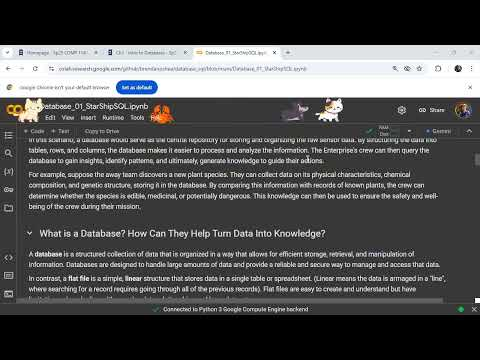

In [ ]:
from IPython.display import YouTubeVideo
YouTubeVideo('ppa-ZFNQJH0', width=800, height=500)

## Introduction to the Case Study: Starship SQL

Welcome aboard the Starship Enterprise. Across this chapter, we will explore database concepts using examples from the adventures of the Enterprise and its crew.

Why a fictional spaceship? Because the same database ideas apply almost everywhere. Whether you are running a starship, a small business, or a global enterprise, the basics of storing, retrieving, and updating data look the same.

Setting the lessons aboard the Enterprise also makes abstract ideas easier to remember. We will see how databases help with concrete problems — organizing crew schedules, analyzing sensor data from a strange planet, tracking encounters with new species — and how the same patterns show up in everyday work.

## What's the Difference Between Data, Information, and Knowledge?

To understand databases, it helps to be clear on three closely related terms. Picture the Enterprise's away team beaming down to a new planet.

**Data** is raw, unorganized facts and figures. The Enterprise's sensors record things like:

- Temperature: 25 °C
- Gravity: 9.8 m/s²
- Radiation: 0.5 mSv/hr
- Soil pH: 6.5
- Atmospheric pressure: 1.01 bar

On their own, these readings do not mean much.

**Information** is data that has been processed and given context. When the ship's computer turns the raw readings into useful statements, the data becomes information:

- The atmosphere is similar to Earth's, with slightly higher oxygen.
- Gravity is close to Earth's, so the crew can move normally.
- Radiation is safe for short visits but risky for long ones.
- The soil is slightly acidic.
- Air pressure is roughly Earth-equivalent at sea level.

**Knowledge** is the understanding and applied judgment that comes from using information. When Spock reviews the atmospheric information and concludes, "Captain, this planet is capable of supporting human life," that is knowledge. He combines the information with his training and experience to reach a decision.

In this scenario, a database is the central place where the raw sensor data lives. By organizing it into tables, rows, and columns, the database makes the data easier to process and analyze. The crew can then query the database to find patterns and produce knowledge that guides their next move.

For example: if the away team finds a new plant, they record its physical traits, chemical makeup, and genetic structure in the database. By comparing it to known plants, they can decide whether the new one is edible, medicinal, or dangerous — the kind of knowledge that keeps the crew alive.

## What is a Database? How Can They Help Turn Data Into Knowledge?

A **database** is a structured collection of data organized for efficient storage, retrieval, and updating. Databases are built to handle large volumes of information reliably and securely.

By contrast, a **flat file** is a simple, linear structure — a single table or spreadsheet. *Linear* here means searching for a record requires reading through the rows one by one. Flat files are easy to create, but they struggle with large datasets and complex relationships.

### A starship example

Suppose the Enterprise crew is cataloging the alien species they encounter. With a flat file, they might use a spreadsheet with columns for species name, planet of origin, physical traits, and tech level.

This works for a small list. As the catalog grows, it gets harder to:

- Search for specific species.
- Update records without introducing errors.
- Keep planet names and tech levels consistent across rows.

A database handles the same job differently. The data is broken into separate tables — one for species, one for planets, one for technology levels — and the tables are linked by relationships. This setup gives the crew:

- A guarantee that each species links to a real planet.
- Built-in checks against duplicate entries.
- One-place updates that flow through to every related record.
- **Queries**: focused searches like "all species from a particular planet" or "all species at warp-capable tech level."

Because data in a database is stored non-linearly, the system can jump straight to the records that match a query instead of scanning every row.

### From data to knowledge

Databases also help turn data into knowledge. Using **data mining**, the science team can uncover patterns in the species catalog. They might find that certain physical traits go with higher tech levels, or that species from particular regions tend to be hostile. That kind of insight then shapes diplomatic and defensive choices on future missions.

### Table: Database vs Flat Files
| **Criterion** | **Databases** | **Flat Files** |
| --- | --- | --- |
| **Data Structure** | Structured with tables, rows, and columns, allowing for complex relationships and queries. | Simple, often plain text or CSV format, with a linear structure and no inherent relationships. |
| **Data Integrity** | Enforced through constraints (e.g., primary keys, foreign keys), ensuring consistency and accuracy. | No built-in mechanisms for enforcing data integrity, leading to potential inconsistencies. |
| **Performance** | Optimized for large-scale data handling with indexing, caching, and query optimization features. | Limited performance, especially with large datasets, as each read/write requires file access. |
| **Concurrency** | Supports multiple concurrent users with transaction management, locking, and isolation levels. | Generally limited to single-user access, or requires complex mechanisms to manage concurrency. |
| **Scalability** | Designed to handle vast amounts of data and can scale horizontally (across servers) or vertically. | Limited scalability, as performance degrades significantly with larger datasets. |

**Interactive activity:** Open this standalone page to use the activity in the Jupyter Book or from Colab.

[Open the Data, Information, and Knowledge quiz](https://brendanpshea.github.io/database_sql/_static/games/data-information-knowledge-quiz.html)

## What is "Data Modeling"?

The first step in building a database is creating a **data model**. Data modeling is the process of analyzing your data — its structure, relationships, and rules — and producing a standard representation of it. That representation acts as a blueprint for the database.

Data modeling starts with understanding the business: what entities (objects or concepts) need to be represented, and how they relate. The goal is a model that reflects the organization's real data needs and supports its work.

Data modeling happens at three levels of abstraction:

1. **Conceptual data model.** A high-level picture of the data and its relationships, with no concern for technology yet. Modelers work with stakeholders to identify key entities and write business rules. Conceptual models are usually drawn as **Entity-Relationship Diagrams (ERDs)**, which show entities, attributes, and relationships visually.

2. **Logical data model.** A refined version of the conceptual model, with concrete attributes, data types, primary keys, foreign keys, and constraints. The logical model is still independent of any specific database product. Depending on the situation, modelers may use a relational model (for SQL databases), a document model (for NoSQL like MongoDB), or another model.

3. **Physical data model.** The logical model translated into a specific database system — actual tables, columns, indexes, and storage settings tuned for performance.

### Worked example: Enterprise mission planning

- **Conceptual.** Identify entities like Mission, Starship, Crew Member, and Planet. Define relationships ("a Mission involves a Starship and a Crew, and may take place on a Planet") and rules ("each Mission must have at least one assigned Crew Member").
- **Logical.** Add attributes (Mission has a start date, end date, and objective). Decide cardinality (a Starship can have many Missions, but a Mission belongs to one Starship). Pick a model — often relational.
- **Physical.** Translate into a real schema in a chosen DBMS, with tables, columns, types, and indexes.

Following these three levels keeps the system well-structured and aligned with the work it has to support. The following sections take a brief tour of the most common logical data models. Later chapters return to each one in depth.

### The Entity-Relationship Model

The **Entity-Relationship (ER) Model** is a visual way to describe data. It is used mainly in the conceptual and logical stages. ERDs are easy enough that technical and non-technical stakeholders can both validate them.

The key components are:

1. **Entities** — distinct objects or concepts (Mission, Starship, Crew Member).
2. **Attributes** — properties of an entity (mission start date, starship name, crew member rank).
3. **Relationships** — how entities connect (a Mission is assigned to a Starship).
4. **Cardinality** — how many of one entity relate to the other (one Starship can have many Missions, but each Mission belongs to one Starship).

ERDs fit into the modeling process in three stages:

- **Conceptual.** A high-level ER diagram shows the main entities and relationships, without all the attributes. Stakeholders use it to confirm the overall shape of the data.
- **Logical.** The diagram is refined with attributes, data types, and cardinality. This more detailed ER model bridges concept and implementation.
- **Physical.** The diagram becomes the actual schema in a chosen database. Entities become tables, attributes become columns, and relationships become primary and foreign keys.

Using the ER Model throughout keeps the data structure well-defined and easy for everyone to understand.

### Example: Conceptual ERD

In [1]:
# @title
import base64
import requests
from IPython.display import SVG, display, HTML

def mm(graph: str) -> None:
    """
    Fetch and display a Mermaid diagram as SVG.

    Parameters:
      graph (str): Mermaid graph definition.
    """
    # 1. Encode the graph to Base64
    b64 = base64.urlsafe_b64encode(graph.encode('utf-8')).decode('ascii')
    # 2. Construct the SVG URL
    url = f'https://mermaid.ink/svg/{b64}'
    # 3. Fetch SVG content
    svg_data = requests.get(url).text
    # 4. Render inline in Jupyter

    display(HTML(f'<div style="width: 50%">{svg_data}</div>'))

mm("""
  erDiagram
        MISSION ||--o{ CREW_MEMBER : "assigned to"
        MISSION ||--|| STARSHIP : "uses"
        MISSION }o--|| PLANET : "explores"
    """)

### Example: Logical ERD

In [2]:
# @title
mm("""
erDiagram
        MISSION_L {
            int mission_id PK
            date start_date
            date end_date
            string objective
            int starship_id FK
            int planet_id FK
        }
        STARSHIP_L {
            int starship_id PK
            string name
            string class
        }
        CREW_MEMBER_L {
            int crew_member_id PK
            string name
            string rank
        }
        PLANET_L {
            int planet_id PK
            string name
            string classification
        }
        MISSION_CREW_L {
            int mission_id FK
            int crew_member_id FK
        }
        MISSION_L ||--o{ MISSION_CREW_L : has
        MISSION_CREW_L }o--|| CREW_MEMBER_L : includes
        MISSION_L ||--|| STARSHIP_L : uses
        MISSION_L }o--|| PLANET_L : explores

""")

### Example: Physical ERD

In [3]:
# @title
mm("""
erDiagram
missions {
            serial mission_id PK
            date start_date
            date end_date
            varchar objective
            int starship_id FK
            int planet_id FK
        }
        starships {
            serial starship_id PK
            varchar name
            varchar class
        }
        crew_members {
            serial crew_member_id PK
            varchar name
            varchar rank
        }
        planets {
            serial planet_id PK
            varchar name
            varchar classification
        }
        mission_crew {
            int mission_id FK
            int crew_member_id FK
        }
        missions ||--o{ mission_crew : has
        mission_crew }o--|| crew_members : includes
        missions ||--|| starships : uses
        missions }o--|| planets : explores
""")

## Logical Data Models: The Relational Model

The **relational model** is the most widely used logical data model, especially in SQL databases. Data is organized into tables (also called *relations*), with rows (*tuples*) and columns (*attributes*). The model is simple, flexible, and powerful.

Key concepts:

1. **Tables** — collections of related rows, each table representing one entity (like "Crew Member" or "Mission").
2. **Columns** — attributes of the entity (Name, Rank, Employee ID).
3. **Rows** — one instance of the entity (one specific crew member or mission).
4. **Primary Key** — a column (or set of columns) that uniquely identifies each row. For Crew Member, Employee ID could be the primary key.
5. **Foreign Key** — a column in one table that points to the primary key of another table, linking them. Mission might have a Crew Member ID foreign key pointing to Crew Member.
6. **Relationships** — connections between tables, defined by primary and foreign keys. The three main kinds are one-to-one, one-to-many, and many-to-many.

### A simple example

The Enterprise's crew management system might use two tables:

**Crew Member Table**

| Employee ID (PK) | Name | Rank | Department ID (FK) |
| --- | --- | --- | --- |
| 1 | James Kirk | Captain | 1 |
| 2 | Spock | Commander | 2 |
| 3 | Uhura | Lieutenant | 3 |
| 4 | Leonard McCoy | Lieutenant | 4 |

**Department Table**

| Department ID (PK) | Department Name |
| --- | --- |
| 1 | Command |
| 2 | Science |
| 3 | Communications |
| 4 | Medical |

Here, Crew Member has the primary key Employee ID and a foreign key Department ID that references the primary key in Department. That foreign key creates a one-to-many relationship: each crew member belongs to one department, but a department can have many crew members.

This structure lets the Enterprise:

- Find all crew members in a given department.
- Join the two tables to pull the department name for each crew member.
- Maintain **referential integrity** — the guarantee that every foreign key points to a real primary key in the other table.

The relational model has been the dominant model since the 1970s. Major systems built on it include Oracle, MySQL, PostgreSQL, Microsoft Access, Microsoft SQL Server, and SQLite. Much of this book focuses on the relational model and SQL, the language used to query it.

## Logical Data Models: JSON and Document Databases

**JSON (JavaScript Object Notation)** is a lightweight, text-based format for representing data. It is widely used in NoSQL databases, especially **document databases**. JSON is well-suited to semi-structured and hierarchical data.

In JSON, data is stored as **key-value pairs** and arrays. Keys are strings, and values can be strings, numbers, booleans, objects, or arrays. Because objects and arrays can nest, JSON supports complex hierarchical structures inside a single document.

```javascript

// Example of a JSON file
// Form is key : value
{
  "crew_id": "001",
  "name": "James Kirk",
  "rank": "Captain",
  "ship": "Enterprise",
  
  // Missions is an example of a "nested" data structure
  "missions": [
    {
      "mission_id": "M001",
      "planet": "Vulcan",
      "objective": "Diplomatic meeting",
      "start_date": "2258-01-15",
      "end_date": "2258-01-18"
    },
    {
      "mission_id": "M002",
      "planet": "Andoria",
      "objective": "Scientific research",
      "start_date": "2258-02-03",
      "end_date": "2258-02-07"
    }
  ],
  "skills": ["Leadership", "Tactics", "Diplomacy"],
  "performance_reviews": [
    {
      "date": "2258-12-31",
      "reviewer": "Admiral Pike",
      "rating": 9,
      "comments": "Exceptional leadership and decision-making skills."
    }
  ]
}

```

**Document databases** like MongoDB and Couchbase use JSON (or a binary form like BSON) to store data as semi-structured documents. Different documents in the same collection can have different fields, so the schema is flexible. That makes it easy to evolve the data as the application changes, without expensive migrations.

Most modern relational databases also support JSON columns natively. Later chapters show how that works in practice.

Key features of document databases:

1. **Flexibility.** Schema-less storage handles semi-structured and unstructured data.
2. **Scalability.** Documents distribute easily across servers, supporting large data volumes and high traffic.
3. **Performance.** Related data lives together in one document, reducing the need for joins.
4. **Expressive queries.** Most document databases support complex queries, indexing, and aggregations on JSON fields.

Document databases and relational databases take different approaches to storage:

- A relational database enforces a strict, predefined schema and spreads data across normalized tables.
- A document database allows flexible, denormalized data inside a single document.

Each fits different needs. Relational databases shine when you need strong consistency, complex transactions, and full **ACID** guarantees (Atomicity, Consistency, Isolation, Durability). Document databases shine when data changes shape often or arrives in irregular formats. The right choice depends on the application's needs around structure, scale, and consistency.

In the Enterprise context, a document database could store mission reports, crew profiles, and sensor readings — situations where each record might have its own quirks. The ability to nest objects and arrays makes JSON a natural fit for these uneven records.

### Logical Model: Graphs for Networks of Connected Information

So far we have seen tables (which organize data in rows and columns) and documents (which nest related information). Graph databases take a different approach: they store data as a **network of connected entities**. They shine when the relationships between things matter as much as the things themselves.

### Understanding graph models

A graph database represents data as a network. Each person, ship, or location is a **node** (or *vertex*). Nodes are connected by **edges** (or *relationships*) that describe how they relate. Both nodes and edges can carry **properties** — extra details about them.

Consider the command structure of the USS Enterprise. Kirk, Spock, and McCoy are each a node. The reporting links between them are edges — Spock and McCoy both have a "reports_to" edge pointing to Kirk. Each node can have properties too: Kirk's might include `rank = "Captain"`, `species = "Human"`, and `assignment_date = "2265"`.

### Real-world applications

Graphs shine in more complex cases. Consider the diplomatic relations of the United Federation of Planets. Each member world is a node, connected by many kinds of relationships: trade agreements, military alliances, cultural exchanges, even conflicts. Earth might have a "founding_member" relationship with the Federation; Vulcan might have both "member_of" and "trade_partner" links to multiple worlds.

That structure makes powerful queries easy:

- Which planets trade with Federation members but aren't members themselves?
- What is the shortest diplomatic chain between Earth and the Klingon Empire?
- Which officers have served under both Captain Kirk and Captain Pike?

Graph databases handle these relationship-heavy questions far better than tables.

### When graph models make sense

Use a graph model when relationships carry meaning of their own. Common cases:

- **Network analysis.** Command structures, supply chains, communication networks.
- **Path finding.** Routes between star systems, or how information spreads.
- **Pattern detection.** Recognizing similar relationship shapes in different parts of the network.
- **Impact analysis.** Tracing how a change in one place affects connected entities.

## Querying graph data

There are two common approaches.

### Property graphs (Neo4j)

In Neo4j, queries are pattern matches:

```cypher
MATCH (officer:Officer)-[:SERVES_ON]->(ship:Starship)
WHERE ship.name = "USS Enterprise"
RETURN officer.name, officer.rank
```

### RDF triples

RDF represents data as subject-predicate-object triples:

```turtle
@prefix starfleet: <http://starfleet.org/ontology/> .
@prefix crew: <http://starfleet.org/crew/> .
@prefix ship: <http://starfleet.org/ship/> .

crew:kirk a starfleet:Officer ;
    starfleet:name "James T. Kirk" ;
    starfleet:rank "Captain" ;
    starfleet:servesOn ship:enterprise .

ship:enterprise a starfleet:Starship ;
    starfleet:name "USS Enterprise" ;
    starfleet:registry "NCC-1701" .
```

Both let you find relationships, with different query languages and conventions. RDF is especially good at linking data across different systems using shared vocabularies.

## Practical considerations

Graph databases are not a universal solution. Simple hierarchical data may fit a document model better. Large analytical queries over uniform data often work better in columnar storage. The right choice depends on the natural shape of the data and how it will be used.

Many modern systems combine models: graphs for relationship-heavy parts, other models for the rest. For Starfleet, personnel assignments and command structures could live in a graph, while sensor logs and maintenance histories might use different models entirely.

## Real-world implementation

A graph model for the Enterprise's crew and missions might look like:

- **Nodes** for crew members, ships, starbases, and planets.
- **Edges** for command structure, ship assignments, and mission participation.
- **Properties** on both nodes and edges:
  - On nodes: name, rank, species, technical specifications.
  - On edges: assignment dates, mission outcomes, relationship types.

With this structure, questions like "What is the chain of command between any two crew members?" become straightforward.

In [4]:
# @title
mm("""
graph TD
    %% Officers
    Kirk[Captain Kirk]
    Spock[Commander Spock]
    McCoy[Dr. McCoy]
    Pike[Admiral Pike]

    %% Ships and Bases
    Enterprise[USS Enterprise]
    Base11[Starbase 11]

    %% Species and Planets
    Human[Humans]
    Vulcan[Vulcans]
    Earth[Earth]
    VulcanPlanet[Vulcan]

    %% Command Structure
    Pike -->|commands| Base11
    Kirk -->|reports to| Pike
    Kirk -->|commands| Enterprise
    Spock -->|reports to| Kirk
    McCoy -->|reports to| Kirk

    %% Ship Assignments
    Enterprise -->|docked at| Base11

    %% Species Relations
    Kirk -->|is a| Human
    Spock -->|is half| Vulcan
    Spock -->|is half| Human
    McCoy -->|is a| Human

    %% Planetary Relations
    Human -->|originates from| Earth
    Vulcan -->|originates from| VulcanPlanet

    %% Styling
    classDef officer fill:#f9f,stroke:#333
    classDef ship fill:#bbf,stroke:#333
    classDef base fill:#bfb,stroke:#333
    classDef species fill:#ffb,stroke:#333
    classDef planet fill:#bff,stroke:#333

    class Kirk,Spock,McCoy,Pike officer
    class Enterprise ship
    class Base11 base
    class Human,Vulcan species
    class Earth,VulcanPlanet planet
""")

## Logical Models: Columns for Analysis

Relational databases handle complex relationships between entities. Document databases handle nested, hierarchical data. There is a third major approach designed for analysis at scale: the **column-oriented** model.

### The core idea: thinking in columns

Consider a mission log organized as a "tidy" table:

| crew_name | mission_date | planet | mission_type | injuries | new_species |
|-----------|--------------|--------|--------------|----------|-------------|
| Kirk      | 2265-03-15   | Vulcan | Diplomatic   | 0        | 0           |
| Spock     | 2265-03-15   | Vulcan | Diplomatic   | 0        | 0           |
| McCoy     | 2265-04-01   | Rigel  | Medical      | 2        | 1           |
| Kirk      | 2265-04-01   | Rigel  | Medical      | 0        | 1           |

A column-oriented system treats each column as its own unit. Instead of storing the data row by row (like a relational database) or as nested documents (like MongoDB), tools like Pandas, DuckDB, and BigQuery organize the same data more like this:

```
crew_name: ["Kirk", "Spock", "McCoy", "Kirk"]
mission_date: ["2265-03-15", "2265-03-15", "2265-04-01", "2265-04-01"]
planet: ["Vulcan", "Vulcan", "Rigel", "Rigel"]
mission_type: ["Diplomatic", "Diplomatic", "Medical", "Medical"]
injuries: [0, 0, 2, 0]
new_species: [0, 0, 1, 1]
```

#### Why organize this way?

The column approach shines for analysis across many rows. Common questions become very efficient:

1. **"What's our average number of injuries per mission?"** Grab the `injuries` column and compute the mean. No other columns need to be touched.
2. **"How many different mission types have we run?"** Grab `mission_type` and count unique values.
3. **"How are missions distributed across planets?"** Focus on `planet` for counting.

#### When to use a column-oriented model

This model works best when:

- You are analyzing patterns across many rows (mission statistics, sales totals).
- Your data fits a "tidy" format: each column is a variable, each row is an observation.
- You do many aggregations (counts, averages, sums).
- Your analysis focuses on a few columns at a time rather than whole rows.

#### When not to use it

Stick to relational or document models when:

- You need to maintain complex relationships between different kinds of data (e.g., crew, positions, missions, outcomes).
- Your data is deeply nested (e.g., ship subsystems within systems).
- You frequently need to look up complete records rather than analyze patterns.

#### Modern tools for column-oriented data

1. **Pandas / R dataframes** — great for analysis in code.

   ```python
   # Average injuries per mission type
   missions.groupby('mission_type')['injuries'].mean()
   ```

2. **DuckDB** — a fast analytical database that thinks in columns.

   ```sql
   SELECT mission_type, AVG(injuries)
   FROM missions
   GROUP BY mission_type;
   ```

3. **BigQuery / Redshift** — cloud databases optimized for column-oriented analytics. Can analyze huge datasets quickly, with automatic column-storage tuning.

The power of the column model comes from matching how you store data to how you analyze it. When the work is about patterns, trends, and aggregates across many rows, column-oriented storage makes that work natural and efficient.

**Interactive activity:** Open this standalone page to use the activity in the Jupyter Book or from Colab.

[Open the Starship data model comparison](https://brendanpshea.github.io/database_sql/_static/games/starship-data-models.html)

## Physical Models: Choosing a DBMS

To store and manage data, you need a **database management system (DBMS)** — the software that lets you create, organize, and interact with a database. Think of it as a sophisticated filing cabinet that keeps your data organized and easy to access.

Several broad categories of DBMS exist, each suited to different problems:

1. **File database (e.g., SQLite).** Lightweight and easy to set up. The entire database is one file on disk. Best for single-user applications and embedded use — picture a personal tricorder with simple local storage needs.

2. **Personal database (e.g., Microsoft Access).** A user-friendly tool for building small applications with tables, forms, and reports. Good for small teams and projects that do not need high scale.

3. **Open-source client-server database (e.g., MySQL, PostgreSQL).** Designed for many concurrent users and substantial workloads. Powerful, scalable, and feature-rich. Common choice for web applications and enterprise systems — fitting for the kind of crew and mission data the Enterprise needs to manage.

4. **Proprietary client-server database (e.g., Oracle, SQL Server).** Aimed at large, mission-critical systems where reliability, performance, and vendor support matter most. These come with extensive tooling and documentation. The kind of system Starfleet headquarters would run for fleet-wide data.

5. **NoSQL database (e.g., MongoDB, Cassandra).** Built for unstructured or semi-structured data — sensor readings, logs, mixed-shape records. Optimized for flexibility, scalability, and high throughput rather than relational integrity.

Different use cases call for different DBMS choices. Managing a few crew records on a single computer might be fine in Access. Running the Enterprise's full sensor and mission data probably means combining a relational system like PostgreSQL with a NoSQL system like MongoDB for the unstructured parts.

# Introduction to SQL: TV Shows Database Lab

## What is SQL?

**SQL (Structured Query Language)** is the standard language for working with relational databases. It is the practical implementation of the relational model: SQL is how you actually create tables, store rows, and ask questions of the data.

## Our first database project: TV Shows

In this lab, you will build a small database to store information about TV shows. We will start with a single table to learn the basics. Later chapters will expand to many related tables.

## Using Jupyter Notebook with SQL

This lab uses Jupyter Notebook with SQLite, a lightweight database system that is perfect for learning. To write SQL inside a notebook, use a code cell that begins with the `%%sql` magic command:

1. Click the **+** button in the toolbar to create a new cell.
2. Type `%%sql` as the first line of the cell.
3. Write your SQL command on the lines that follow.
4. Run the cell to execute the SQL.

(Code cells are already set up for you below.)

## Tips for success

- End every SQL statement with a semicolon (`;`).
- By convention, SQL keywords are written in **UPPERCASE**, but it is not required.
- Wrap string values in single quotes (`'like this'`).
- If you make a mistake, drop the table and start over:

   ```sql
   %%sql
   DROP TABLE IF EXISTS shows;
   ```

## Your task

1. Create the `shows` table using the template provided.
2. Add at least five of your favorite TV shows to the database.
3. Try each query type below with your own data.
4. Experiment! Combine concepts (for example, sort filtered data).

In [ ]:
%pip install --quiet jupysql
# Load SQL magic and connect to the chapter database
%load_ext sql
%config SqlMagic.autopandas = True
%sql sqlite:///movie.sqlite

## SQL Instructions and Templates

### 1. Creating a Table
First, we need to create a table to store our TV show data. The CREATE TABLE command defines the structure of our table and the types of data it will store.

```sql
%%sql
CREATE TABLE shows (
    id INTEGER PRIMARY KEY,
    title TEXT,
    genre TEXT,
    release_year INTEGER,
    rating DECIMAL
);
```


In [7]:
%%sql
-- First, drop table if it already exists
DROP TABLE IF EXISTS shows;

 * sqlite:///movie.sqlite
Done.


""


In [8]:
%%sql
CREATE TABLE shows (
    id INTEGER PRIMARY KEY,
    title TEXT,
    genre TEXT,
    release_year INTEGER,
    rating DECIMAL
);

 * sqlite:///movie.sqlite
Done.


""



### 2. Adding Data: Single Row
To add one TV show to our database, we use the INSERT INTO command.

```sql
%%sql
INSERT INTO shows (title, genre, release_year, rating)
VALUES ('Your Show Title', 'Genre', 2024, 8.5);
```


In [9]:
%%sql
INSERT INTO shows (title, genre, release_year, rating)
VALUES ('Your Show Title', 'Your Genre', 2024, 8.5);

 * sqlite:///movie.sqlite
Done.


""



### 3. Adding Multiple Rows
We can add multiple shows at once using multiple VALUES clauses.

```sql
%%sql
INSERT INTO shows (title, genre, release_year, rating)
VALUES
    ('First Show', 'Genre1', 2020, 8.5),
    ('Second Show', 'Genre2', 2021, 9.0),
    ('Third Show', 'Genre1', 2022, 7.8);
```


In [10]:
%%sql
INSERT INTO shows (title, genre, release_year, rating)
VALUES
    ('First Show', 'Genre1', 2020, 8.5),
    ('Second Show', 'Genre2', 2021, 9.0),
    ('Third Show', 'Genre1', 2022, 7.8);

 * sqlite:///movie.sqlite
Done.


""



### 4. Retrieving All Data
To see all the data in our table, we use SELECT with an asterisk (*).

```sql
%%sql
SELECT * FROM shows;
```


In [11]:
%%sql
SELECT * FROM shows;

 * sqlite:///movie.sqlite
Done.


""



### 5. Selecting Specific Columns
We can retrieve only the columns we're interested in.

```sql
%%sql
SELECT title, rating
FROM shows;
```



In [12]:
%%sql
SELECT title, rating
FROM shows;

 * sqlite:///movie.sqlite
Done.


""



### 6. Filtering Data
The WHERE clause lets us filter our results based on conditions.

```sql
%%sql
SELECT title, genre, rating
FROM shows
WHERE rating >= 8.0;
```


In [13]:
%%sql
SELECT title, genre, rating
FROM shows
WHERE rating >= 8.0;

 * sqlite:///movie.sqlite
Done.


""



### 7. Sorting Data
ORDER BY helps us sort our results.

```sql
%%sql
SELECT title, release_year, rating
FROM shows
ORDER BY rating DESC;
```



In [14]:
%%sql
SELECT title, release_year, rating
FROM shows
ORDER BY rating DESC;

 * sqlite:///movie.sqlite
Done.


""


### 8. Counting Records
We can count how many shows meet certain criteria.

```sql
%%sql
SELECT COUNT(*) as show_count
FROM shows
WHERE genre = 'Your Genre';
```

In [15]:
%%sql
SELECT COUNT(*) as show_count
FROM shows
WHERE genre = 'Your Genre';

 * sqlite:///movie.sqlite
Done.


""



### 10. Updating Data
We can modify existing data using the UPDATE command.

```sql
%%sql
UPDATE shows
SET rating = 9.5
WHERE title = 'Your Show Title';
```


In [16]:
%%sql
UPDATE shows
SET rating = 9.5
WHERE title = 'Your Show Title';

 * sqlite:///movie.sqlite
Done.


""


In [17]:
%%sql
-- Now, see the results.
SELECT * FROM shows;

 * sqlite:///movie.sqlite
(sqlite3.OperationalError) no such table: shows
[SQL: -- Now, see the results.
SELECT * FROM shows;]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


### 11. Using AI to Generate Sample Data

The **Gemini** AI built into Colab can help you generate realistic TV show data. Here's the workflow:

1. Open the Gemini window and type a prompt describing what you want:

   ```text
   Generate 10 INSERT statements for the shows table with realistic TV show data.
   Include popular shows from different genres and years.
   Format: INSERT INTO shows (title, genre, release_year, rating) VALUES ('title', 'genre', year, rating);
   ```

2. Let Gemini draft the INSERT statements. You might get something like:

   ```sql
   INSERT INTO shows (title, genre, release_year, rating) VALUES
   ('Breaking Bad', 'Drama', 2008, 9.5),
   ('The Office', 'Comedy', 2005, 8.9),
   ('Stranger Things', 'Sci-Fi', 2016, 8.7),
   ('The Crown', 'Drama', 2016, 8.6),
   ('Friends', 'Comedy', 1994, 8.8);
   ```

3. Review the suggestions and edit as needed. You can also ask Gemini to:
   - Cover more genres.
   - Focus on a specific decade.
   - Restrict the rating range.

Tips for working with AI:

- Be specific in your prompt.
- Spot-check the data for accuracy.
- Ask for more examples or different shapes if needed.
- Verify the SQL syntax before running it.

In [18]:
%%sql
INSERT INTO shows (title, genre, release_year, rating) VALUES
('Breaking Bad', 'Drama', 2008, 9.5),
('The Office', 'Comedy', 2005, 8.9),
('Stranger Things', 'Sci-Fi', 2016, 8.7),
('The Crown', 'Drama', 2016, 8.6),
('Friends', 'Comedy', 1994, 8.8);

 * sqlite:///movie.sqlite
Done.


""


In [19]:
%%sql
SELECT * FROM shows;

 * sqlite:///movie.sqlite
Done.


""


### 12. Pattern Matching with LIKE
The LIKE operator is a powerful tool for searching text patterns. It uses two special characters:
- `%` matches any sequence of characters (including zero characters)
- `_` matches exactly one character

Here are some useful pattern matching examples:

```sql
%%sql
-- Find shows that start with "The"
SELECT title FROM shows WHERE title LIKE 'The%';

-- Find shows that end with "Show"
SELECT title FROM shows WHERE title LIKE '%Show';

-- Find shows with "and" anywhere in the title
SELECT title FROM shows WHERE title LIKE '%and%';

-- Find shows with exactly 5 characters
SELECT title FROM shows WHERE title LIKE '_____';

-- Find shows that start with 'B' and have 'r' as the third letter
SELECT title FROM shows WHERE title LIKE 'B_r%';
```

Write a query using LIKE

In [20]:
%%sql
SELECT title
FROM shows
WHERE title LIKE 'The%';

 * sqlite:///movie.sqlite
Done.


""


## 13. Have Fun!
You've learned the basics of SQL (we'll learn lots more as we go through the class). Now, it's your turn to play with it. Make a new table about a topic that interests you, and see what you can discover.

In [21]:
%%sql
SELECT 'Student workspace: Replace this scaffold with your own SQL.' AS note;

UsageError: %%sql is a cell magic, but the cell body is empty. Did you mean the line magic %sql (single %)?


In [ ]:
%%sql
SELECT 'Student workspace: Replace this scaffold with your own SQL.' AS note;

In [ ]:
%%sql
SELECT 'Student workspace: Replace this scaffold with your own SQL.' AS note;

### Table: Leading Database Management Systems
| DBMS | Description | Supported Logical Models |
| --- | --- | --- |
| Oracle | A powerful, enterprise-level database system known for its scalability and reliability, often used by large organizations. | Relational, JSON, XML, Spatial |
| MySQL | A popular, open-source database system widely used for web applications, offering simplicity and good performance. | Relational, JSON (MySQL 5.7+) |
| Microsoft SQL Server | A robust database system developed by Microsoft, providing scalability, security, and integration with other Microsoft products. | Relational, JSON (SQL Server 2016+), XML, Spatial |
| Microsoft Access | A user-friendly, small-scale database system included in the Microsoft Office suite, suitable for personal projects and small businesses. | Relational |
| SQLite | A lightweight, file-based database system commonly used as an embedded database in applications, known for its simplicity and efficiency. | Relational, JSON (partial) |
| MongoDB | A flexible, document-oriented NoSQL database that stores data in JSON-like formats, designed for scalability and agile development. | Document (JSON), Geospatial |
| Apache Cassandra | A highly scalable, distributed NoSQL database built to handle large amounts of structured data across multiple servers. | Wide Column Store |
| Amazon DynamoDB | A fully managed NoSQL database service provided by Amazon Web Services, offering automatic scaling and low latency data access. | Key-value, Document (JSON) |
| PostgreSQL | A powerful, open-source database system known for its reliability, robustness, and support for advanced data types. | Relational, JSON, XML, Spatial, Key-value (Hstore) |
| IBM Db2 | An enterprise-level database system developed by IBM, offering scalability, reliability, and advanced analytics capabilities. | Relational, JSON, XML, Spatial |

## Advanced Data Storage Concepts

This section covers four core concepts in data management: **databases**, **data lakes**, **data warehouses**, and **data marts**. Each builds on the others, and together they cover most of how organizations store and use data.

### (Relational) databases: the foundation

A **database** is an organized collection of data stored and accessed electronically. The most common type is a **relational database**, which organizes data into tables of rows and columns. The relational model was proposed by E. F. Codd in 1970.

Key features of relational databases:

1. **Data integrity** — accurate, consistent records.
2. **ACID properties** — reliable transaction processing.
3. **Normalization** — structured to reduce redundancy.
4. **Indexing** — tuned for fast queries.

Relational databases excel at structured data with clear relationships. They are less flexible when the data is unstructured or its shape changes often. That limitation led to the other storage concepts below.

### Data lakes: raw, unstructured storage

A **data lake** is a repository that holds large amounts of raw data in its original format until someone needs it. A data lake can hold structured, semi-structured, and unstructured data side by side.

Key characteristics:

1. **Schema-on-read** — the data's structure is not defined until you query it.
2. **Any data type** — text, images, sensor logs, telemetry.
3. **Highly scalable** — easy to grow as data volume grows.
4. **Cost-effective** — often runs on commodity hardware.

In a Star Trek context, a data lake might hold sensor logs, crew reports, and alien artifact scans, all in their original formats.

Data lakes are useful for big-data analytics and machine learning, where analysts want to explore data in ways that were not predetermined by a schema.

### Data warehouses: integrated data for analysis

A **data warehouse** is a central store of integrated data drawn from many sources, designed for reporting and analysis. Data warehouses use an **ETL (Extract, Transform, Load)** process to pull data from those sources, clean and standardize it, and load it in.

Key features:

1. Organized around major subjects (customers, products, missions).
2. Data from many sources is merged into one consistent format.
3. Keeps historical data so trends can be analyzed.
4. **Non-volatile** — updates happen in batches, not in real time.

Data warehouses often use a **star schema** or **snowflake schema** — variations of the relational model optimized for analytical queries. These schemas have a central fact table linked to multiple dimension tables.

Starfleet might use a data warehouse to analyze trends across every starship mission, integrating ship logs, personnel records, and scientific findings into one place.

### Data marts: focused subsets of a warehouse

A **data mart** is a slice of a data warehouse focused on one team or business line. It is a smaller, more targeted warehouse.

Key aspects:

1. Tailored to one business function or department.
2. Holds less data than a full warehouse.
3. Queries run faster because the scope is narrower.
4. Often used to enforce **security** — people only see the data they need.

Two common approaches:

- **Top-down.** Built from an existing enterprise data warehouse.
- **Bottom-up.** Built first, possibly merged into a larger warehouse later.

In the Star Trek scenario, Starfleet might run a central warehouse while departments like Security or Engineering keep their own data marts tuned to their specific work.

In [22]:
# @title
mm("""
graph TD
    A[Transactional Databases<-  Store day-to-day operations.<br>Examples: Crew logs, replicator orders, sensor data.]
    -->|ETL Process  - Extract, Transform, Load| B[Data Warehouse - Stores structured data for analysis.<br>Examples: Analyzing energy use or mission trends.]
    A -->|Raw Data Ingestion - Store as-is| C[Data Lake - Stores raw, unstructured data.<br>Examples: Sensor scans, raw logs, probe data.]
    C -->|Transform Data - Process for analysis| B
    B -->|Specific Subset - Focused Data| D[Data Mart - Specialized part of a data warehouse.<br>Examples: Warp core analysis for engineering.]

""")

**Interactive activity:** Open this standalone page to use the activity in the Jupyter Book or from Colab.

[Open the data storage systems quiz](https://brendanpshea.github.io/database_sql/_static/games/data-storage-systems-quiz.html)

## Chapter Summary

Use this list as a self-check. After working through the chapter, you should be able to do each of the following:

- You can distinguish data, information, and knowledge, and explain how databases turn data into knowledge.
- You can name the advantages databases offer over flat files for organization, retrieval, and consistency.
- You can describe the conceptual, logical, and physical levels of data modeling.
- You can compare relational, document (JSON), and graph data models and pick one for a given scenario.
- You can weigh DBMS choices and the trade-offs between cloud and local storage.
- You can explain how databases, data lakes, data warehouses, and data marts relate to one another.

## Practice with the Loop of the Recursive Dragon

Sharpen what you just learned with a chapter-matched review set in the **Loop of the Recursive Dragon** — an adaptive review game with multiple question types and RPG-style mechanics, built for this book.

[**Launch the Chapter 1 review set →**](https://brendanpshea.github.io/LotRD/?set=database_01_foundations.json)

## Glossary

Use this list as a quick review sheet for the chapter.

- **Data** — Raw, unorganized facts and figures.
- **Information** — Facts that have been organized and given context so they carry meaning.
- **Knowledge** — Understanding built from information and shaped by applied judgment.
- **Database** — A structured collection of records organized for fast storage, retrieval, and updating.
- **Flat file** — A single table or spreadsheet with no built-in relationships between rows.
- **Data consistency** — The state of having no contradictions across the system's records.
- **Data integrity** — The quality of being accurate, complete, and reliable.
- **Data model** — A representation of structure, relationships, and rules for a set of records.
- **Conceptual model** — A high-level view of the main entities and how they relate, without technology details.
- **Logical model** — A detailed design of structure and relationships that does not yet pick a specific database system.
- **Physical model** — A design tied to a particular database management system, with concrete tables, types, and storage choices.
- **Relational model** — A way of organizing records into tables made up of rows and columns.
- **Table** — A set of related rows and columns inside a relational database.
- **Attribute** — A single column that stores one kind of value for every row.
- **Primary key** — A column or set of columns that uniquely identifies each row in a table.
- **Foreign key** — A column or set of columns that points to a primary key in another table.
- **Document model** — A model that stores semi-structured records, often in JSON format.
- **JSON** — A text format that represents data as key-value pairs and arrays.
- **Key (document model)** — The name part of a key-value pair.
- **Value (document model)** — The actual data stored under a given key.
- **Graph model** — A model that stores records as nodes and the relationships between them as edges.
- **Node** — A single entity inside a graph database.
- **Edge** — A connection between two nodes in a graph database.
- **Database Management System (DBMS)** — Software used to create, organize, and manage databases.
- **Structured data** — Information arranged in a predefined format, usually rows and columns.
- **Unstructured data** — Information without a fixed structure, such as free text, images, or video.
- **NoSQL database** — A non-relational database designed for flexible or very large-scale data.
- **Data lake** — A repository that stores raw structured, semi-structured, and unstructured data in its native format.
- **Data warehouse** — A central store of structured data drawn from many sources and optimized for reporting and analysis.
- **Data mart** — A smaller warehouse focused on one team, department, or subject area.
- **Scalability** — The ability of a system to handle more work or more data as needs grow.
- **Schema-on-read** — An approach that applies structure when data is read, rather than when it is stored.